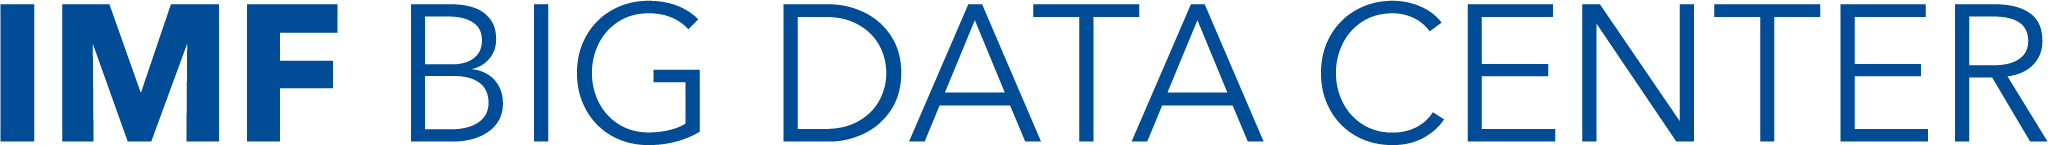

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AlessandraSozzi/STI_2026/blob/main/notebooks/BDC_Challenge_GDP_Nowcasting.ipynb)

# Big Data Challenge: Nowcasting China GDP Using Satellite Data and Machine Learning

---

<br>**Contributors:**
<br> **Last update:**
<br> **Description:** This notebook is a group challenge to nowcast China's GDP growth from satellite-derived indicators, covering model training, error metrics, Shapley explainability and retraining on a rolling window
<br> **References:**

## Set-up

Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Install and import libraries.

⚠ **May need to restart session**

In [ ]:
#install shapley and pdp packages
!pip install shap pdpbox

Import Packages

In [ ]:
# import related libraries
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt # Moved this import here
import math
from pandas import DataFrame
from pandas import concat
from numpy import concatenate
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
import pdpbox.pdp as pdp
import shap
import time
import pickle
import shap
import os
from PIL import Image
from sklearn.model_selection import TimeSeriesSplit
from pdpbox import pdp, get_example, info_plots
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.metrics import mean_absolute_error

### Import data

In [ ]:
ROOT = "/content/drive/MyDrive/STI 2026/" #if using colab

workspace = "Day 4-5 - Capstone Project/"
data_folder = "Data"
data_path = os.path.join(ROOT, workspace, data_folder)
data_path

In [ ]:
# Check
os.path.exists(data_path)

▶ Remember you can use 'BDC_Data_Extract_Satellite_Data' and 'BDC_Data_Preprocessing_for_GDP_Nowcasting' to extract and process data for another country. However, data extraction may take long.

In [ ]:
# Read the CSV file into a Pandas DataFrame
filename = 'model_data_chn.csv'
filepath = os.path.join(data_path, filename)
df_imported = pd.read_csv(filepath)

#df_imported.drop(columns=['Month', 'Year_current'], inplace=True)
df_imported
df=df_imported
df.index=df.index.astype(str)

In [ ]:
df.describe()

In [ ]:
df_imported.tail()

### Data processing

In [ ]:
column_list = df.columns.tolist()
print(column_list)

Keep only relevant columns

In [ ]:
col = ['index', 'year_current', 'diff_sum_ntl', 'diff_sum_evi', 'diff_sum_ndvi', 'diff_sum_no2', 'diff_sum_pcp', 'diff_sum_asi', 'diff_sum_ndvi_anomaly', 'diff_sum_vhi', 'diff_gti_tourism', 'GDP']
df = df[col]

In [ ]:
# year as string
df['year_current'] = df['year_current'].astype(str).str[:4]
df.rename(columns={'year_current': 'year'}, inplace=True)


Data is already pre-processed: imputed missing values and taken differences to make them stationary

In [ ]:
df.tail(12)

In [ ]:
# clean up the column names
df.columns= df.columns.str.replace('diff_sum_', '').str.replace('diff_', '')

In [ ]:
df.tail()

In [ ]:
# Display the correlation matrix
correlation_matrix = df.corr(numeric_only=True)
display(correlation_matrix)

# Display the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

Save clean dataset

In [ ]:
filename = 'df_clean.csv'
filepath = os.path.join(data_path, filename)
df.to_csv(filepath, index=False)

Visually explore data

In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

# Add first series (Trademarks Filings Growth)
fig.add_trace(go.Scatter(x=df['index'], y=df['asi'], mode='lines', name='asi'))

# Add second series (Designs Filings Growth)
fig.add_trace(go.Scatter(x=df['index'], y=df['gti_tourism'], mode='lines', name='gti_tourism'))

# Add third series (GDP) on a secondary y-axis
fig.add_trace(go.Scatter(x=df['index'], y=df['GDP'], mode='lines', name='GDP', yaxis='y2'))

# Update layout to include a secondary y-axis
fig.update_layout(
    title="China's Non-traditional data vs. GDP Growth",
    xaxis_title='Date',
    yaxis_title='Growth Rate (%)',
    yaxis2=dict(
        title='GDP Growth Rate (%)',
        overlaying='y',
        side='right'
    )
)

fig.show()

## **Train the model**

scikit learn makes available a wide range of models. For details: https://scikit-learn.org/stable/api/sklearn.ensemble.html

### Initial training
Split the data at 85:15 % train test, based on time series

In [ ]:
# For time series splits, reproducibility is typically handled by the data ordering itself.
# If using methods like train_test_split, a random_state would be used.
# 'index' is the name of the date column in the DataFrame
df_ = df.copy()
df_.drop(df_.tail(1).index,inplace=True) # drop latest observation where GDP is missing
# Include the quarter (index) column in the features before splitting
display(len(df_))

initial_window_size = len(df_.index) - 4 # Use all rows except the last 4 for training, the rest for testing

training = df_.iloc[:initial_window_size]
test = df_.iloc[initial_window_size:]

train_X = training.drop('GDP', axis=1)
train_y = training['GDP']
test_X = test.drop('GDP', axis=1)
test_y = test['GDP']

#display(test_X.tail())
#display(test_y.tail())

# drop index column
train_X = train_X.drop('index', axis=1)
test_X = test_X.drop('index', axis=1)

Train model on the initial window (85% data)

In [ ]:
# train a random forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(train_X, train_y)

### Predict on test dataset

In [ ]:
# Make predictions on the test data
predictions = model.predict(test_X)

# # Plot actual vs. predicted values with dates on the x-axis

plt.figure(figsize=(5, 2))
plt.plot(test['index'], test_y, label='Actual')
plt.plot(test['index'], predictions, label='Predicted')
plt.xlabel('index')
plt.ylabel('Value')
plt.title('Actual vs. Predicted test_data')
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()


### Generate error metrics, MAE and RMSE

In [ ]:
# Calculate Mean Squared Error
mse = mean_squared_error(test_y, predictions)
mae = mean_absolute_error(test_y, predictions)

# Calculate Root Mean Squared Error
rmse = np.sqrt(mse)

print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print("mean absolute error:", mae)

### Model explainability using shapley decomposition

In [ ]:
# Fits the explainer/Create object that can calculate shap values.
# (1) Create the 'explainer' using the model fit on the full training set, e.g. see (1) https://github.com/slundberg/shap (2) https://www.youtube.com/watch?v=CV9FTCvQ32Q (timestamp - 10:43)
# (2) Calculate shap values for the test set, e.g. (1) https://www.youtube.com/watch?v=ZkIxZ5xlMuI

explainer = shap.Explainer(model, seed=42) # same used by SHAP author, only include the model - https://github.com/slundberg/shap, note that xgb_model contains both preditor and target vaiables, so the explainer can understnad this realtionship
# Calculates the SHAP values. SHAP calculation time is lengthy, so your only choice is to run this on the test set, not the fulll data or train
# Note that this is being run on the test set
shap_values = explainer(test_X)


In [ ]:
# SHAP Dependence Plot — Global Interpretability with contributing factors
shap.plots.bar(shap_values)

In [ ]:
# SHAP waterfall plot for Explainable Contribution
shap.plots.waterfall(shap_values[0], show=True)


## **Retrain the model**

### **Retrain the model on rolling window**

Helper function: Define function for training and retraining models


In [ ]:
def retrain_and_predict(data, model, window_size, horizon=1):
    """
    Trains a Random Forest model on a rolling window of data and predicts the next value.

    Args:
        data (pd.DataFrame): The full dataset with features and target.
        model (RandomForestRegressor): The scikit-learn model to retrain.
        window_size (int): The number of recent data points to train the model on.
        horizon (int): The number of future steps to predict.

    Returns:
        tuple: A tuple containing the updated model and the latest prediction.
    """
    # Define the training window
    train_data = data[-window_size:]

    # Separate features (X) and target (y)
    X_train = train_data.drop('GDP', axis=1)
    y_train = train_data['GDP']

    X_train = X_train.drop('index', axis=1) # drop index column

    # Retrain the model on the rolling window
    model.fit(X_train, y_train)

    # Prepare the latest available data for prediction
    latest_X = data.drop('GDP', axis=1).iloc[-horizon:]

    latest_X = latest_X.drop('index', axis=1)  # drop index column

    # Make the nowcast prediction
    nowcast = model.predict(latest_X)

    return model, nowcast

Simulate nowcasting loop with retraining

In [ ]:
print("\n--- Simulating Retraining Loop ---")
rolling_window_size = initial_window_size + 4
num_retraining_steps = 4
predictions = []

for i in range(num_retraining_steps):
    # Simulate a new data point arriving
    new_data_point_index = initial_window_size + i
    new_df = df_.iloc[:new_data_point_index+1]

    # Retrain the model on the latest rolling window
    rf_model, new_prediction = retrain_and_predict(new_df, model, rolling_window_size)

    predictions.append(new_prediction[0])

    # Print results to show the nowcast adapting
    actual_value = df_['GDP'].iloc[new_data_point_index]

    print(f"Time Step: {df_.index[new_data_point_index]}")
    print(f"  Nowcast: {new_prediction[0]:.4f}")
    print(f"  Actual:  {actual_value:.4f}")
    print("-" * 20)

# --- Evaluate performance on the last predictions ---
actuals = df_['GDP'].iloc[initial_window_size : initial_window_size + num_retraining_steps]
rmse = np.sqrt(mean_squared_error(actuals, predictions))
print(f"\n--- Final Evaluation ---")
print(f"RMSE over the last {num_retraining_steps} predictions: {rmse:.4f}")

Predict the missing GDP growth value using the retrained model

In [ ]:
# The last row of the original dataframe 'df' contains the missing GDP value
latest_data = df.iloc[[-1]].copy()

In [ ]:
display(latest_data)

In [ ]:
# Predict the missing GDP growth value using the retrained model

# Separate features (X) for prediction
X_latest = latest_data.drop('GDP', axis=1)
X_latest = X_latest.drop('index', axis=1) # drop index column

# Make the prediction
predicted_missing_gdp = model.predict(X_latest)

print(f"The predicted GDP growth for the missing period is: {predicted_missing_gdp[0]:.4f}")

### **Retrain the model on 100% of the data**

In [ ]:
df_1 = df.copy()
df_1.drop(df_1.tail(1).index,inplace=True)


In [ ]:
train_Xa, train_ya = df_1.iloc[:-1, 1:-1], df_1.iloc[:-1, -1]
test_Xa, test_ya = df_1.iloc[:, 1:-1], df_1.iloc[:, -1]

In [ ]:
# Train Random Forest model
model_all = RandomForestRegressor(n_estimators=100, random_state=42)
model_all.fit(train_Xa, train_ya)

In [ ]:
predictions = model_all.predict(test_Xa)
# Calculate Mean Squared Error
mse = mean_squared_error(test_ya, predictions)
mae = mean_absolute_error(test_ya, predictions)

# Calculate Root Mean Squared Error
rmse = np.sqrt(mse)

print('Mean Squared Error:', mse)
print('Root Mean Squared Error:', rmse)
print("mean absolute error:", mae)

Predict the missing GDP Growth using the model trained on 100% of the data

In [ ]:
test_Xr = df.iloc[:, 1:-1]
test_Yr = df.iloc[:, -1]

In [ ]:
# Make predictions on the test data
all_predictions = model_all.predict(test_Xr)


In [ ]:
all_predictions

### Compare model predictions

In [ ]:
# Compare predictions from both models
comparison_df = df[['index', 'GDP']].copy()
comparison_df['initial_model_predictions'] = model.predict(df.drop(['index', 'GDP'], axis=1))
comparison_df['all_data_model_predictions'] = model_all.predict(df.drop(['index', 'GDP'], axis=1))

display(comparison_df)

### Plot model predictions

In [ ]:
# Plot actual vs. predicted values with Years on the x-axis
# Convert 'index' to datetime if not already done (important for plotting time series)
comparison_df['index'] = pd.to_datetime(comparison_df['index'])

plt.figure(figsize=(15, 7)) # Increase figure size for better readability
sns.lineplot(data=comparison_df, x='index', y='GDP', label='Actual', marker='o', color='skyblue') # Use seaborn for nicer line plots and markers
sns.lineplot(data=comparison_df, x='index', y='initial_model_predictions', label='Initial Model Nowcast', linestyle='dashed', color='salmon', marker='o') # Plot initial model predictions
sns.lineplot(data=comparison_df, x='index', y='all_data_model_predictions', label='All Data Model Nowcast', linestyle='dotted', color='lightgreen', marker='o') # Plot all data model predictions


# Plot the last point from the 'all_data_model_predictions' with a distinct marker and label
last_row_all_data = comparison_df.iloc[[-1]].reset_index(drop=True)
plt.scatter(last_row_all_data['index'], last_row_all_data['all_data_model_predictions'], label=f"{last_row_all_data['index'].dt.strftime('%Y-%m-%d').iloc[0]}-nowcast ({last_row_all_data['all_data_model_predictions'].iloc[0]:.3f})", color='forestgreen', s=100, zorder=5) # Increase size and zorder for visibility, update label

plt.xlabel('QUARTER', fontsize=12) # Increase label font size
plt.ylabel('GDP_GROWTH-RATE', fontsize=12) # Increase label font size
plt.title('Actual vs. Nowcast GDP Growth Comparison', fontsize=14, fontweight='bold') # Increase title font size and add bold
plt.legend(fontsize=10) # Increase legend font size

plt.xticks(rotation=90, ha='center')  # Rotate x-axis labels vertically for better readability and center alignment
plt.grid(True, linestyle='--', alpha=0.6) # Add a grid for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping

plt.show()

In [ ]:
# Filter the DataFrame to include data from 2019-10-01 onwards
comparison_df_filtered = comparison_df[comparison_df['index'] >= '2019-10-01'].copy()

# Plot actual vs. predicted values with Years on the x-axis
last_row_filtered = comparison_df_filtered.iloc[[-1]].reset_index(drop=True)

plt.figure(figsize=(15, 7)) # Increase figure size for better readability
sns.lineplot(data=comparison_df_filtered, x='index', y='GDP', label='Actual', marker='o', color='skyblue') # Use seaborn for nicer line plots and markers
sns.lineplot(data=comparison_df_filtered, x='index', y='initial_model_predictions', label='Initial Model Nowcast', linestyle='dashed', color='salmon', marker='o') # Plot initial model predictions
sns.lineplot(data=comparison_df_filtered, x='index', y='all_data_model_predictions', label='All Data Model Nowcast', linestyle='dotted', color='lightgreen', marker='o') # Plot all data model predictions

# Plot the last point from the 'all_data_model_predictions' with a distinct marker and label
plt.scatter(last_row_filtered['index'], last_row_filtered['all_data_model_predictions'], label=f"{last_row_filtered['index'].dt.strftime('%Y-%m-%d').iloc[0]}-nowcast ({last_row_filtered['all_data_model_predictions'].iloc[0]:.3f})", color='forestgreen', s=100, zorder=5) # Increase size and zorder for visibility, update label

plt.xlabel('QUARTER', fontsize=12) # Increase label font size
plt.ylabel('GDP_GROWTH-RATE', fontsize=12) # Increase label font size
plt.title('Actual vs. Nowcast GDP Growth Comparison (Since 2019-10-01)', fontsize=14, fontweight='bold') # Increase title font size and add bold
plt.legend(fontsize=10) # Increase legend font size

plt.xticks(rotation=90, ha='center')  # Rotate x-axis labels vertically for better readability and center alignment
plt.grid(True, linestyle='--', alpha=0.6) # Add a grid for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping

plt.show()

### Save predictions and the model

In [ ]:
df_to_save=df_imported.copy()
df_to_save["predicted_gdp"]=all_predictions
df_to_save = df_to_save[['index','GDP','predicted_gdp']]
df_to_save.to_csv('saved_data.csv')
df_to_save

Save the predictions to a file

In [ ]:
filename = 'chn_pred_data.csv'
filepath = os.path.join(data_path, filename)

df_to_save.to_csv(filepath, index=False)


Save the model to a file

In [ ]:
filename = 'model_chn.pkl'
filepath = os.path.join(data_path, filename)

with open(filepath, 'wb') as f:
    pickle.dump(model, f)


▶ **Try with different models, tuning parameters, add other datasets, etc.**
